In [ ]:
import pandas as pd
import numpy as np
from math import log2
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ml/praktikum07/data/college.csv")
df.head()

,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,male,53900,118,encourage,plan
1,4561,female,24900,87,not encourage,not plan
2,4563,female,65800,93,not encourage,not plan
3,4565,male,11440,117,encourage,plan
4,4567,female,16700,102,not encourage,not plan


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudentID      8000 non-null   int64 
 1   Gender         8000 non-null   object
 2   Parent_income  8000 non-null   int64 
 3   IQ             8000 non-null   int64 
 4   Encourage      8000 non-null   object
 5   Plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB


In [ ]:
df.isnull().sum()

,0
StudentID,0
Gender,0
Parent_income,0
IQ,0
Encourage,0
Plan,0


In [ ]:
df.duplicated().sum()

np.int64(0)

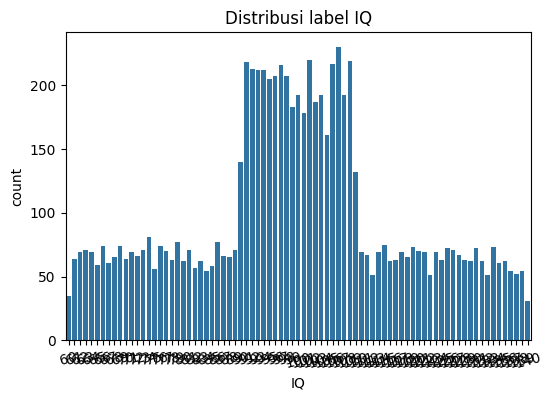

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='IQ', data=df)
plt.title('Distribusi label IQ')
plt.xticks(rotation=15)
plt.show()

In [11]:
# mapping label -> kode untuk target
iq_cat = df['IQ'].astype('category')
iq_classes = list(iq_cat.cat.categories)   # urutan kelas
df['IQ'] = iq_cat.cat.codes                # y numerik

# fitur kategorikal lain (jenis_kelamin, wasting) -> kode juga
for col in ['Gender', 'Encourage', 'Plan']:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

df.head()


,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,1,53900,58,0,1
1,4561,0,24900,27,1,0
2,4563,0,65800,33,1,0
3,4565,1,11440,57,0,1
4,4567,0,16700,42,1,0


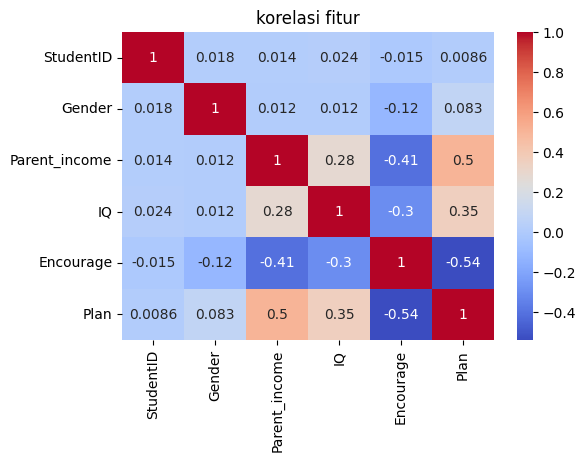

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title('korelasi fitur')
plt.show()

In [14]:
# Memilih fitur dan target

X = df['Parent_income']
y = df['IQ']


In [15]:
# Membagi dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)


(6400, 1600)

In [17]:
# Membangun model
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

# Reshape X_train to be 2-dimensional
dt.fit(X_train.values.reshape(-1, 1), y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [20]:
# Evaluasi
y_pred = dt.predict(X_test.values.reshape(-1, 1))

print("Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=[str(x) for x in iq_classes]
))

Akurasi: 3.12 %

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00        14
           3       0.00      0.00      0.00        14
           4       0.00      0.00      0.00        14
           5       0.00      0.00      0.00        12
           6       0.00      0.00      0.00        15
           7       0.00      0.00      0.00        12
           8       0.00      0.00      0.00        13
           9       0.00      0.00      0.00        15
          10       0.00      0.00      0.00        13
          11       0.00      0.00      0.00        14
          12       0.00      0.00      0.00        13
          13       0.00      0.00      0.00        14
        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TypeError: can only concatenate str (not "int") to str

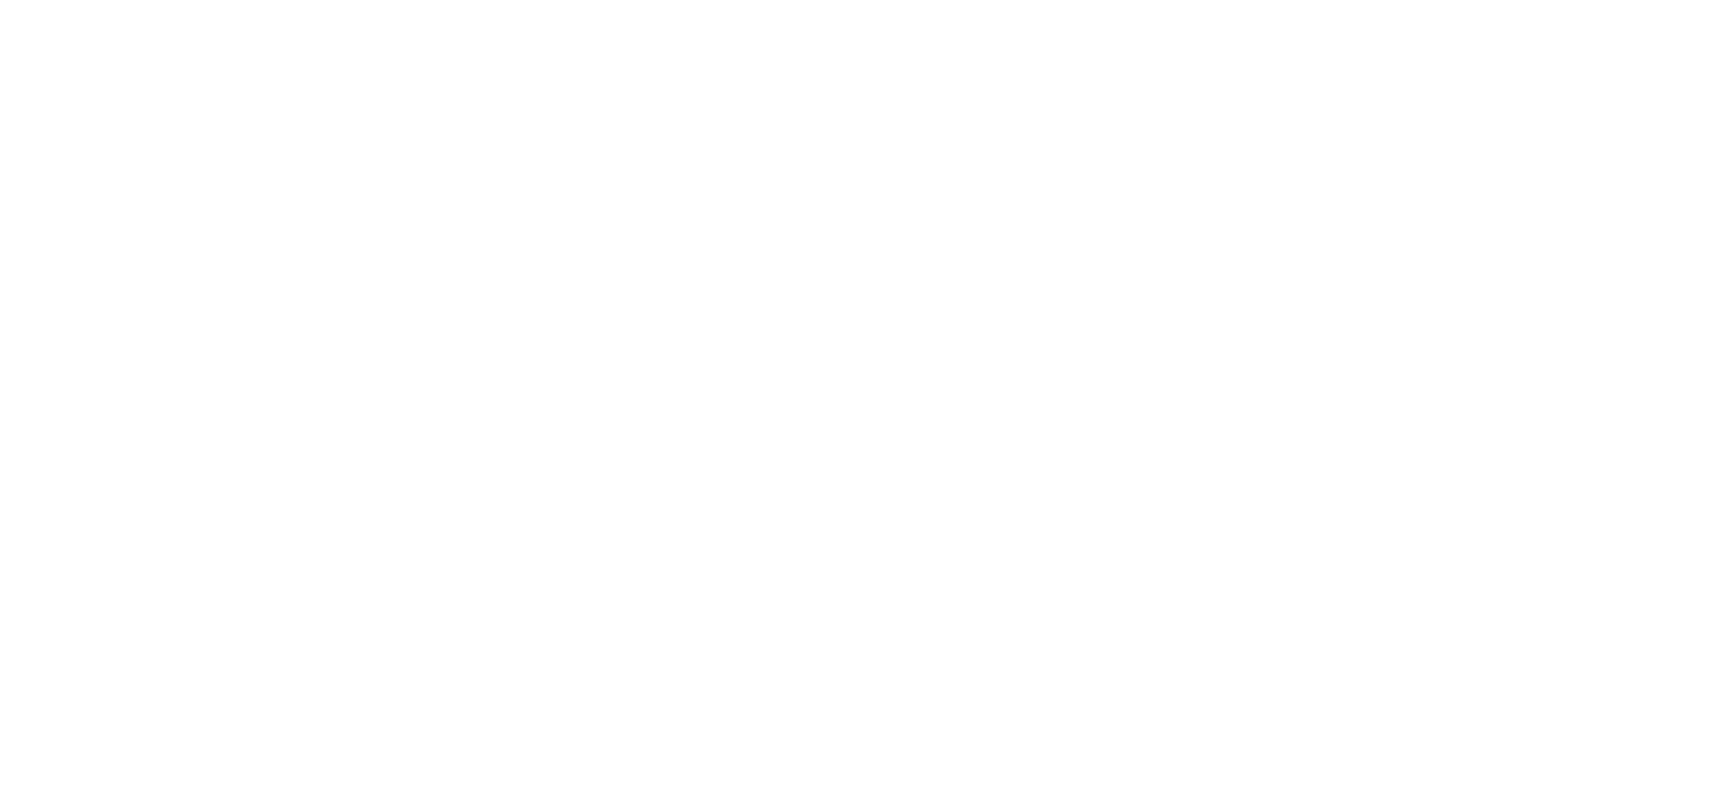

In [24]:
# Visualisasi model
plt.figure(figsize=(22,10))
feature_cols = ['Parent_income'] # Define feature_cols here
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=iq_classes,  # kembali ke nama kelas asli
    filled=True,
    fontsize=9
)
plt.title("Decision Tree - Klasifikasi IQ")
plt.show()